In [2]:
!pip install yfinance


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

stock_data = yf.download('AAPL', start='2026-01-01')

[*********************100%***********************]  1 of 1 completed


In [4]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-02,270.756653,277.580254,268.748522,272.005484,37838100
2026-01-05,267.010162,271.256189,265.891214,270.387007,45647200
2026-01-06,262.114716,267.299866,261.874950,266.750392,52352100
2026-01-07,260.086609,263.433483,259.567106,262.953951,48309800
2026-01-08,258.797852,259.047618,255.460962,256.779720,50419300


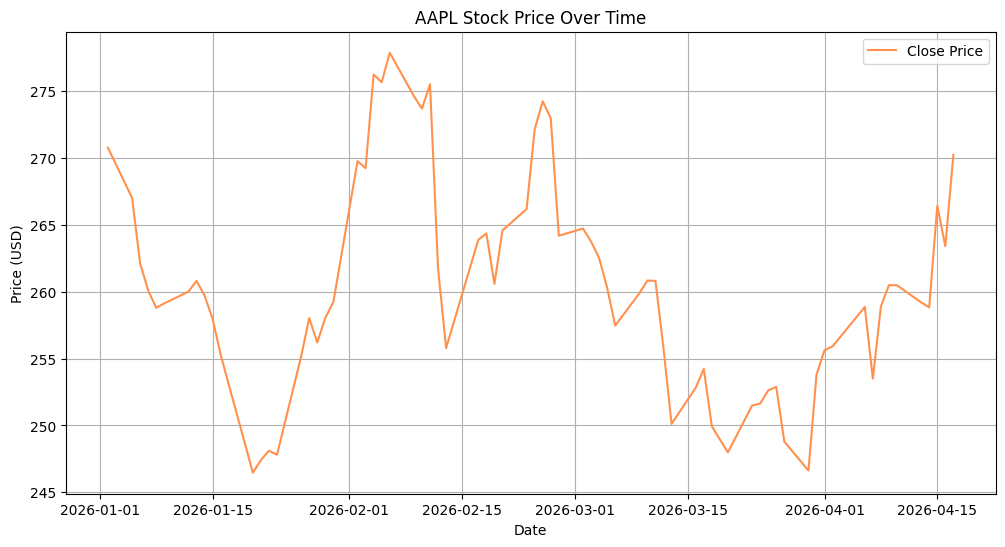

In [5]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color='#FF914D')
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Classical Time Series Decompostion

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(stock_data['Close'], model='additive', period=30)

In [7]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

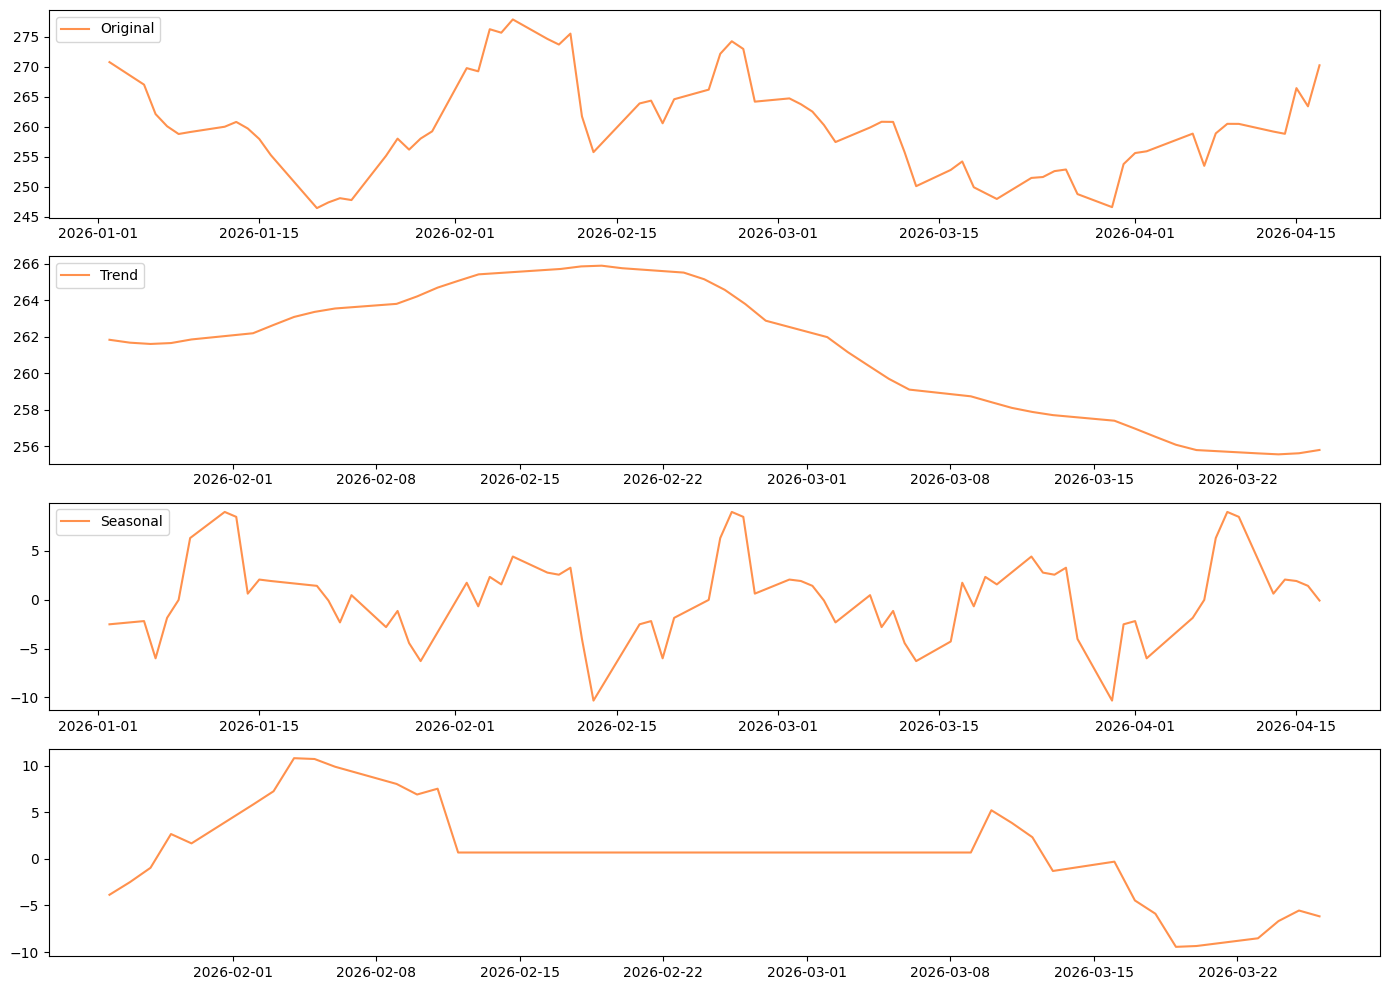

In [8]:
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(stock_data['Close'], label='Original', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend_additive, label='Trend', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal_additive, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual_additive, label='Residual', color='#FF914D')
plt.tight_layout()
plt.show()


## STL Decomposing

In [1]:
from statsmodels.tsa.seasonal import STL

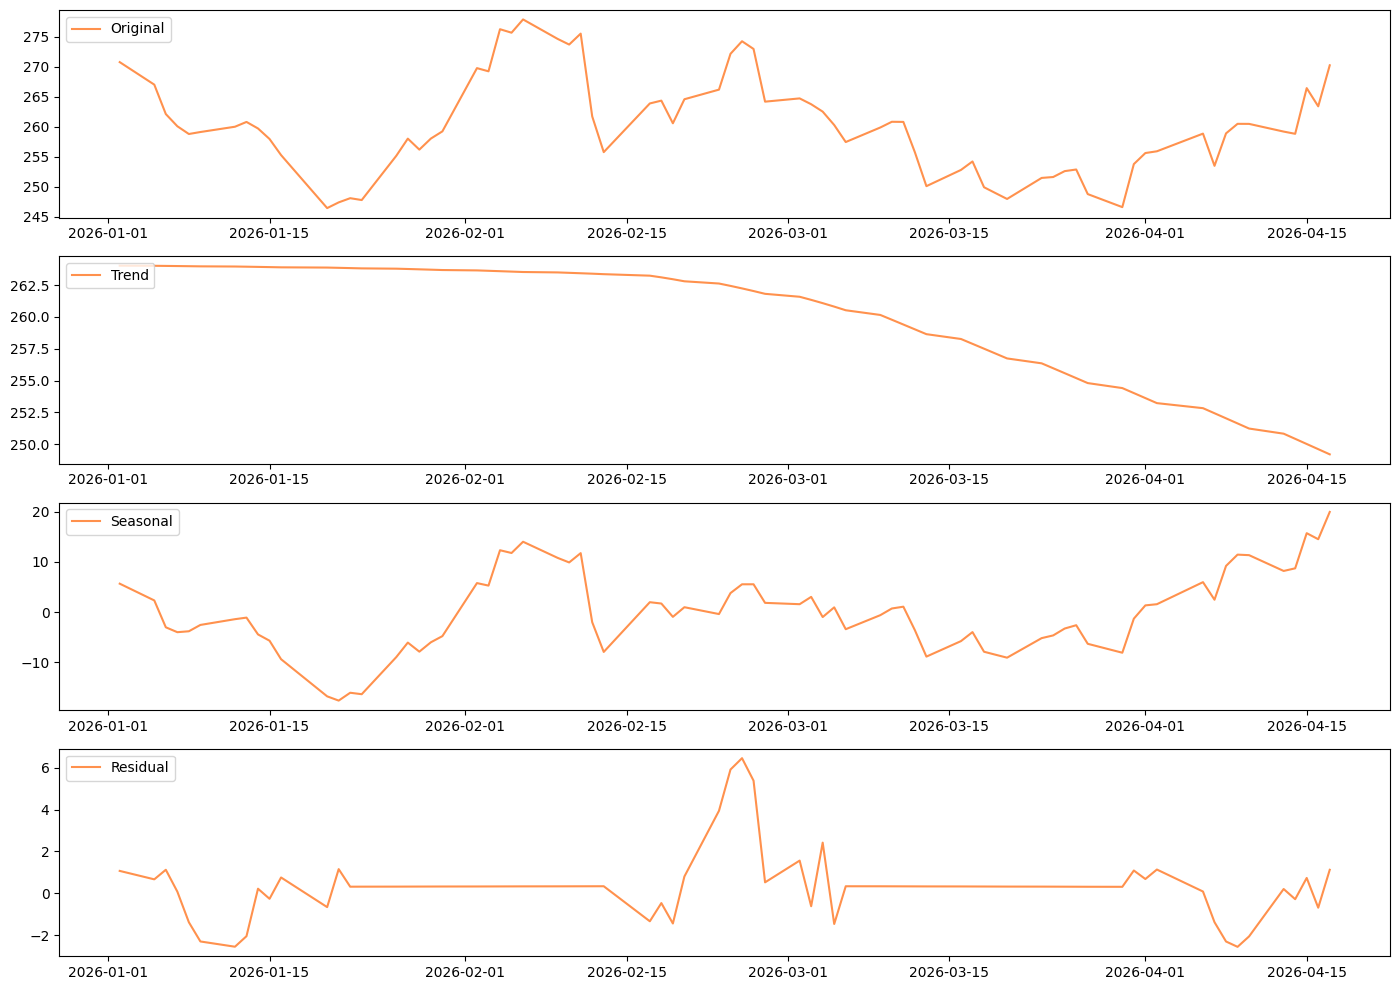

In [10]:
stl = STL(stock_data['Close'], period=30)
result = stl.fit()

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(result.observed, label='Original', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend, label='Trend', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid, label='Residual', color='#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Stationarity Test

In [11]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-fuller test
ad_test = adfuller(stock_data['Close'])

print('ADF Test Results: ')
print(f'ADF Statistic: {round(ad_test[0], 3)}')
print(f'p-value: {round(ad_test[1], 3)}')
print('Critical Values: ')
for key, value in ad_test[4].items():
    print(f'    {key}: {round(value,3)}')

ADF Test Results: 
ADF Statistic: -2.265
p-value: 0.184
Critical Values: 
    1%: -3.525
    5%: -2.903
    10%: -2.589


In [12]:
from statsmodels.tsa.stattools import kpss

# Perform the KPSS test
kpss_test = kpss(stock_data['Close'], regression='ct')  # 'c' for constant (level stationarity), 'ct' for trend

print('KPSS Test Results: ')
print(f'KPSS Statistic: {round(kpss_test[0], 2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key, value in kpss_test[3].items():
    print(f'    {key}: {value}')

KPSS Test Results: 
KPSS Statistic: 0.12
p-value: 0.1
Critical Values:
    10%: 0.119
    5%: 0.146
    2.5%: 0.176
    1%: 0.216


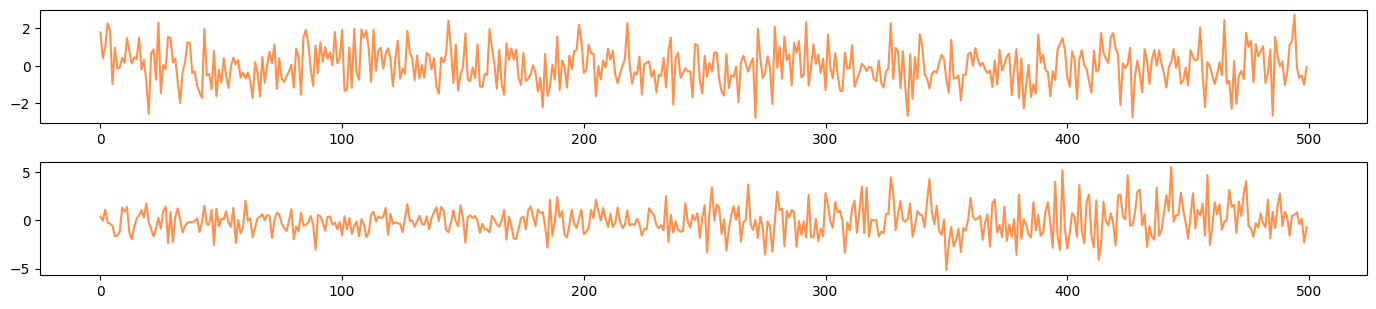

Strict Stationary Series - K-S Test Statistic: 0.068, p-value: 0.6109
Weak Stationary Series - K-S Test Statistic: 0.184, p-value: 0.0004


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Generating synthectic data for demonstration
np.random.seed(0)
n = 500

# Strictly staionary series: normally distributed random noise
strict_stationary_series = np.random.normal(0, 1, n)

# Non-strictly stationary series: changing variance
non_strict_stationary_series = np.concatenate([
    np.random.normal(0, 1, n // 2),
    np.random.normal(0, 2, n // 2)
])

# Function to split the series into two halves and perform the K-S test
def ks_test_stationarity(series):
    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    stat, p_value = ks_2samp(series_first_half, series_second_half)
    return stat, p_value

# Perform the K-S test on strictly stationary series
ks_stat_strict, ks_pvalue_strict = ks_test_stationarity(strict_stationary_series)

# Perform the K-S test on non-strictly stationary series
ks_stat_non_strict, ks_pvalue_non_strict = ks_test_stationarity(non_strict_stationary_series)

# Plotting the series
plt.figure(figsize=(14, 6))
plt.subplot(411)
plt.plot(strict_stationary_series, label='Strict Stationary Series', color='#FF914D')
plt.subplot(412)
plt.plot(non_strict_stationary_series, label='Weak Stationary Series', color='#FF914D')
plt.tight_layout()
plt.show()

print(f'Strict Stationary Series - K-S Test Statistic: {ks_stat_strict}, p-value: {ks_pvalue_strict:.4f}')

print(f'Weak Stationary Series - K-S Test Statistic: {ks_stat_non_strict}, p-value: {ks_pvalue_non_strict:.4f}')